# Introduction to LLMs in Python

## Using Hugging Face models

In [1]:
from transformers import pipeline

In [ ]:
summarizer = pipeline(
    task = "summarization",
    model = "facebook/bart-large-cnn",
    clean_up_tokenization_spaces = True
    )

text = """
Walking amid Gion's Machiya wooden houses is a mesmerizing experience. The 
beautifully preserved structures exuded an old-world charm that transports visitors 
back in time, making them feel like they had stepped into a living museum. The glow of 
lanterns lining the narrow streets add to the enchanting ambiance, making each stroll a 
memorable journey through Japan's rich cultural history."
"""

summary = summarizer(text, min_length=25, max_length=50)

Device set to use mps:0


In [2]:
print("Summary:", summary[0]['summary_text'])

Summary: Gion's Machiya wooden houses exuded an old-world charm that transports visitors back in time. The glow of lanterns lining the narrow streets add to the enchanting ambiance.


## Using pre-trained LLMs

### Text generation

In [3]:
generator = pipeline(task="text-generation", model="distilgpt2")

prompt = "In a distant future, humanity has"

output = generator(prompt, max_length=100, pad_token_id = generator.tokenizer.eos_token_id)

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use mps:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [4]:
print(output[0]['generated_text'])

In a distant future, humanity has a new technology to use. It is a new technology that is now used for the first time.




"We are working on a new technology that uses the power of our magnetic field and our magnetic field to create a super-stable planet. We are exploring the possibilities of the new technology, but we are still trying to make sure that it is able to be used in the future of our planet, in the future of our planet.
"
The idea of a super-stable planet is one of the most promising and innovative technologies that we have seen in recent years.
"
The idea of a super-stable planet is one of the most promising and innovative technologies that we have seen in recent years.
"
The idea of a super-stable planet is one of the most promising and innovative technologies that we have seen in recent years.
"
The idea of a super-stable planet is one of the most promising and innovative technologies that we have seen in recent years.
"
"
The concept of a super-stable planet is one of 

### Translation

In [2]:
translator = pipeline(task="translation_en_to_es", model="Helsinki-NLP/opus-mt-en-es")

text = "Walking amid Gion's Machiya wooden houses is a mesmerizing experience."

output = translator(text, clean_up_tokenization_spaces=True)

print("Translation:", output[0]['translation_text'])

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/Users/martinalvarez/Desktop/developing llms/venv/lib/python3.13/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use mps:0


Translation: Caminar entre las casas de madera Machiya de Gion es una experiencia fascinante.


# Understanding the transformer

Transformers are deep learning based architectures for processing text. Most SOTA LLMs use this architecture because they can handle long text sequences instead of processing each word sequentially. There are three common architectures:

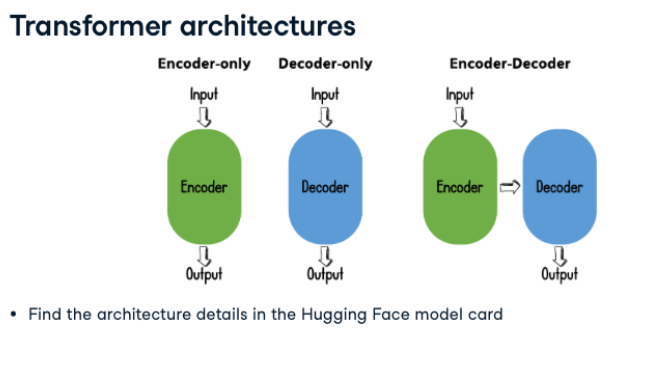

## Encoder-Only

This architecture is focused on **encoding and understanding input text**, without producing a sequential output (for example a sentence)

It is commonly used for **text classification, sentiment analysis, and extractive question-answering**

Some examples of this architecture are BERT-based models

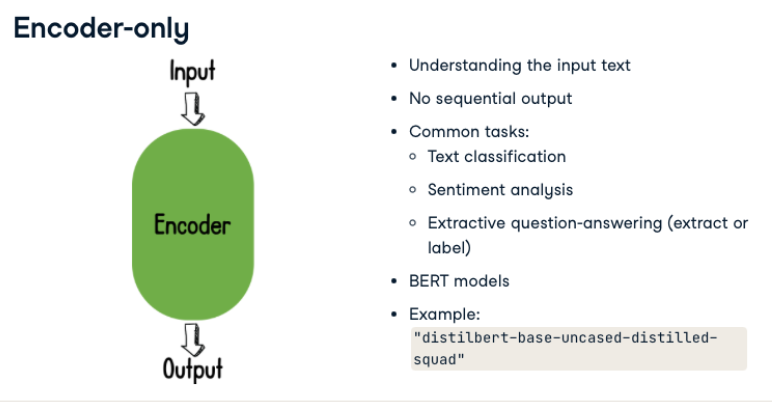

the code below will help us see architectural details:

In [3]:
llm = pipeline(model="bert-base-uncased")
print(llm.model)

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


BertForMaskedLM(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwi

In [3]:
print(llm.model.config)

BertConfig {
  "architectures": [
    "BertForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "gradient_checkpointing": false,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "model_type": "bert",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "transformers_version": "4.57.3",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}



now, we want to know specifically if this is encoder-decoder model

In [4]:
print(llm.model.config.is_decoder)

False


In [5]:
print(llm.model.config.is_encoder_decoder)

False


## Decoder-only

This architecture is primarily focused on text generation, tasks where sentences or paragraphs have to be generated. For example:

- Text generation
- Generative question-answering

Examples of this architecture are GPT-based models

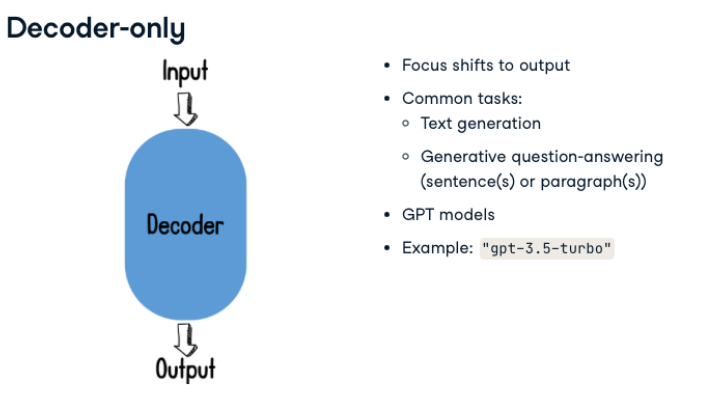

In [2]:
llm = pipeline(model="gpt2")
print(llm.model.config.is_decoder)

Device set to use mps:0


False


llm.model.config.is_decoder returns false, examining the structure and usage can indicate it's a decoder-only model.

In [3]:
print(llm.model.config)

GPT2Config {
  "activation_function": "gelu_new",
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "transformers_version": "4.57.3",
  "use_cache": true,
  "vocab_size": 50257
}



## Encoder-decoder

This type of model combines the previous two, helping the model understand and process both the input and output.

Tasks include:

- summarization
- translation

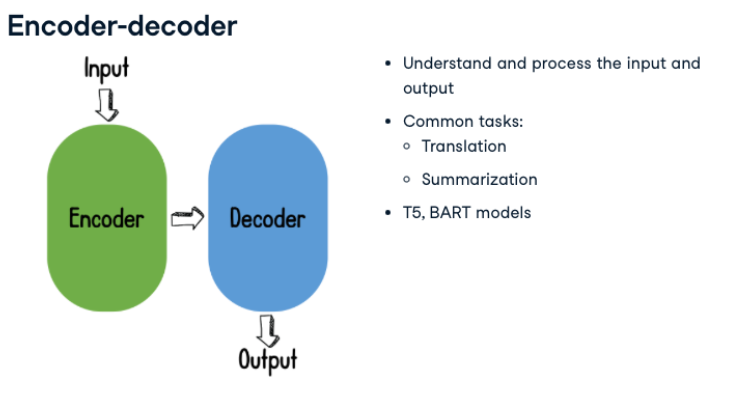

Some examples of this model architecture are T5 and BART

In [1]:
from transformers import pipeline

llm = pipeline(model="Helsinki-NLP/opus-mt-es-en")

/Users/martinalvarez/ds-ml-ai-learning/developing-llms/venv/lib/python3.13/site-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use mps:0


this output shows us the "decoder" and "encoder" elements

In [2]:
print(llm.model)

MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(65001, 512, padding_idx=65000)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(65001, 512, padding_idx=65000)
      (embed_positions): MarianSinusoidalPositionalEmbedding(512, 512)
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (final_layer_norm): LayerNorm((512,), eps=1e-05

In [3]:
print(llm.model.config.is_encoder_decoder)

True


# Fine Tuning

until this point we have used the **pipeline()** interface, which given a task, it will automatically choose the model and tokenizer but offering limited control.

The **Auto Classes** allow more customization, enabling manual adjustments and model fine tuning.

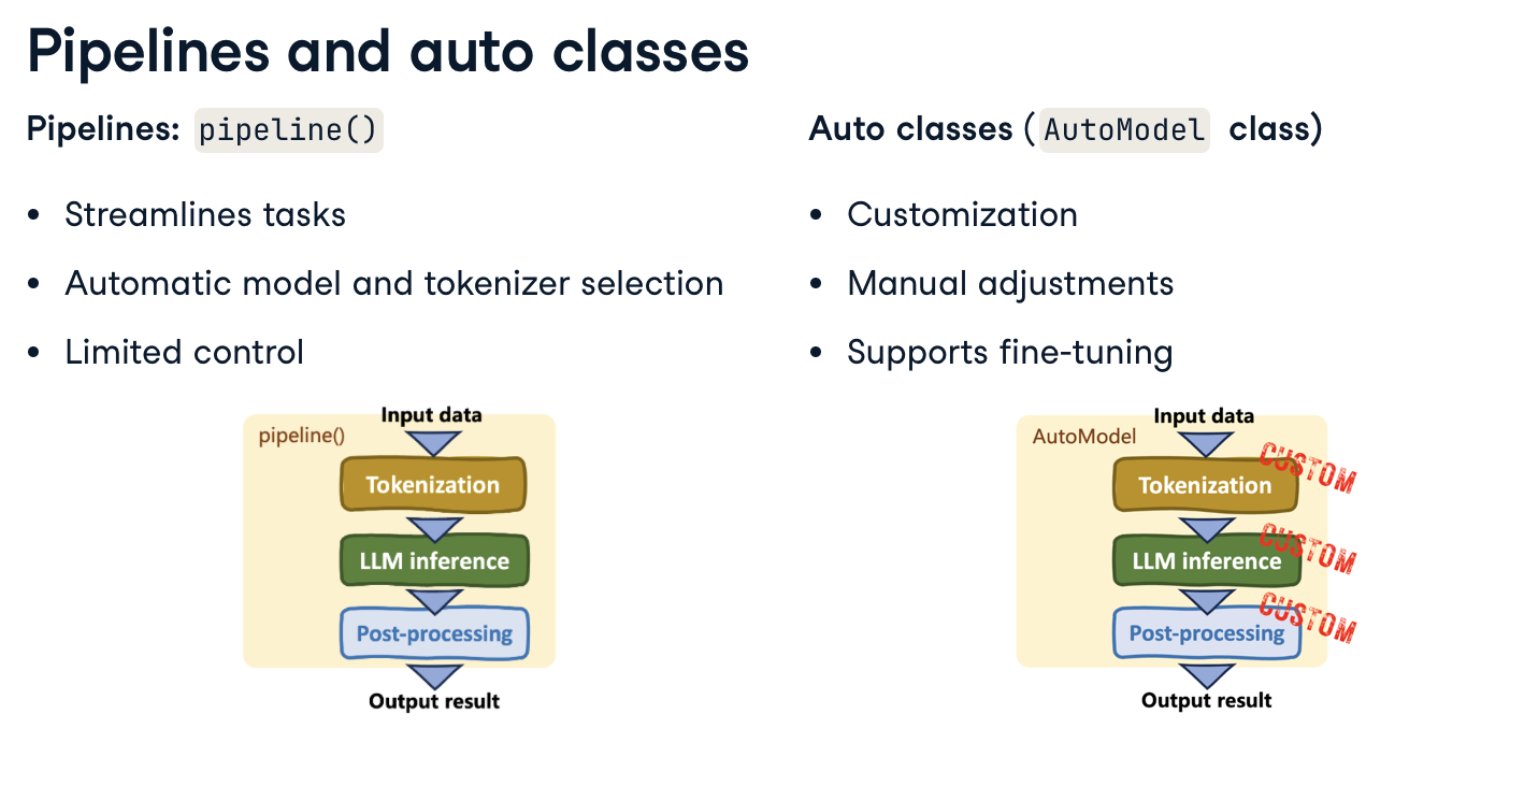

## LLM Lifecycle

The LLM development lifecycle is similar to other machine and deep learning models. However, LLM training has two phases:

- pre-training on a broad dataset to learn general language patterns,

- fine-tuning on domain specific data to adapt it for specialized tasks.

For instance, an insurance company's data used to fine-tune an LLM to handle insurance customer inquiries.

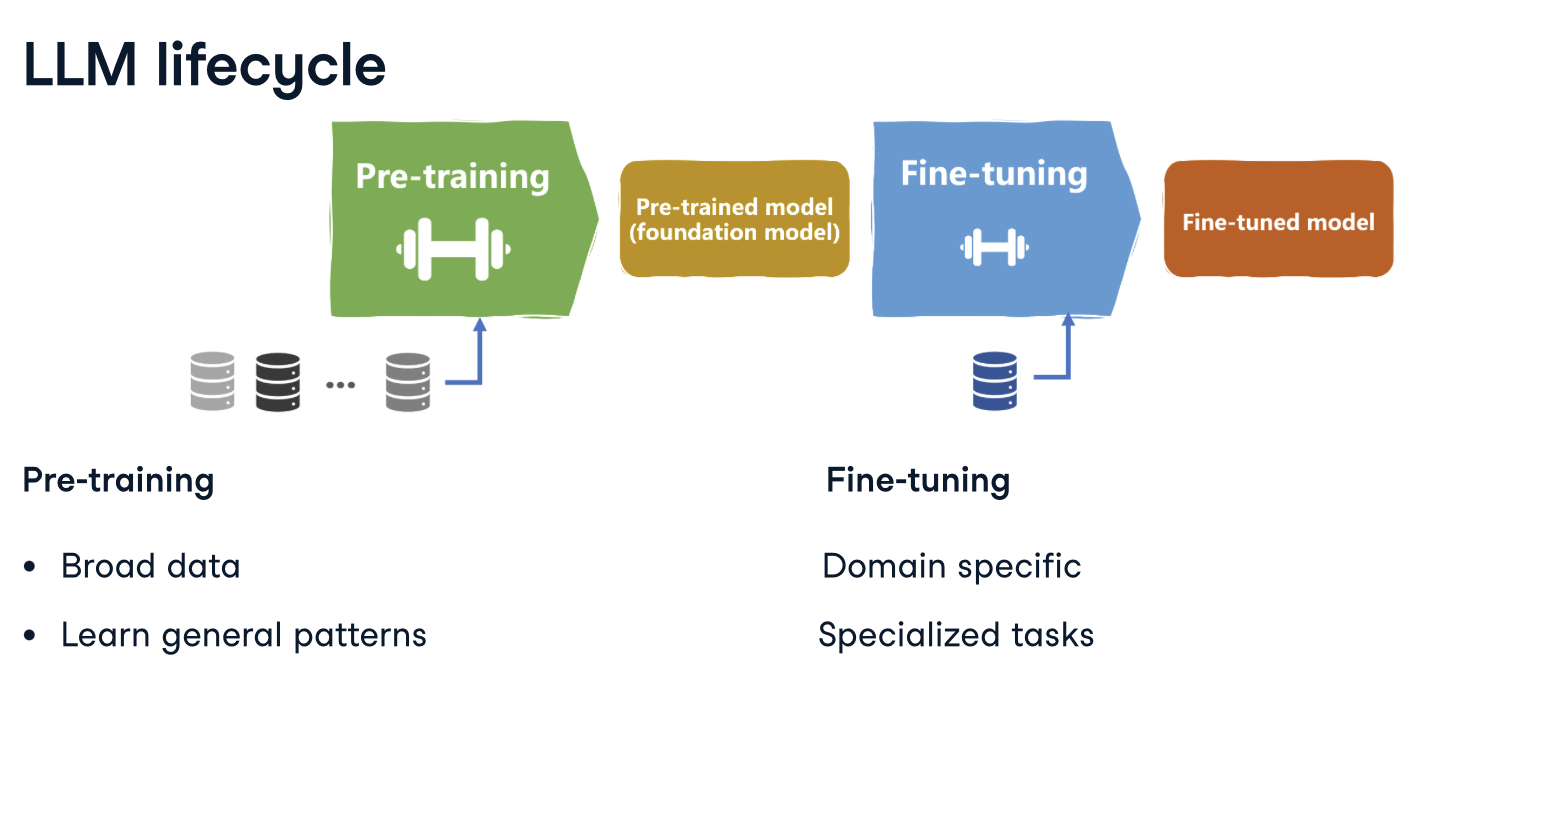

### Loading a dataset for fine tuning

In [17]:
from datasets import load_dataset

train_data = load_dataset("imdb", split="train")
train_data = train_data.shard(num_shards=4, index=0)

test_data = load_dataset("imdb", split="test")
test_data = test_data.shard(num_shards=4, index=0)

In [18]:
train_data.to_pandas().head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [19]:
print(train_data[0]['text'])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

In [20]:
len(train_data.to_pandas())

6250

### Tokenizing the data

In [21]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

# 1. Create a function that defines exactly how to tokenize a batch
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length", # "max_length" is safer here than True
        truncation=True,
        max_length=64
    )

# 2. Apply this function across your datasets using .map()
# batched=True processes multiple rows at once for speed
tokenized_data_train = train_data.map(tokenize_function, batched=True)
tokenized_data_test = test_data.map(tokenize_function, batched=True)

# 3. Format the datasets to return PyTorch tensors
tokenized_data_train.set_format(type="torch", columns=["input_ids", "token_type_ids", "attention_mask", "label"])
tokenized_data_test.set_format(type="torch", columns=["input_ids", "token_type_ids", "attention_mask", "label"])

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

In [22]:
print(tokenized_data_train)

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6250
})


### Tokenizing row by row or in batches

In [23]:
def tokenize_function(text_data):
    return tokenizer(
        text_data['text'],
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=64
        )

tokenize_in_batches = train_data.map(tokenize_function, batched=True)

tokenized_by_row = train_data.map(tokenize_function, batched=False)

Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

## Fine tuning through training

### Training Arguments

* `TrainingArguments()`: customize training settings
* `output_dir`: output directory
* `eval_strategy`: when to evaluate "epoch", "steps", or "none"
* `num_train_epochs`: number of training epochs
* `learning_rate`: for optimizer
* `per_device_train_batch_size` and `per_device_eval_batch_size` define the batch size
* `weight_decay` : applied to the optimizer to avoid overfitting


In [24]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir = "./finetuned",
    eval_strategy = "epoch",
    learning_rate = 2e-5,
    num_train_epochs = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 8,
    weight_decay = 0.01,
)    

### Training Class

* `model` : the model to fine-tune
* `args` : the training arguments
* `train_dataset` : the data used for training
* `eval_dataset` : the data used for evaluation
* `tokenizer` : the tokenizer

**Number of training loops: Dataset size,**
`num_train_epochs`,
`per_device_train_batch_size` and
`per_device_eval_batch_size`

In [25]:
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = tokenized_data_train,
    eval_dataset = tokenized_data_test,
    tokenizer = tokenizer
)

trainer.train()

trainer.save_model("./finetuned")
tokenizer.save_pretrained("./finetuned")

/var/folders/fs/frgxymqd7qn62mstscf1g38h0000gn/T/ipykernel_70408/1570834916.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/Users/martinalvarez/ds-ml-ai-learning/developing-llms/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss
1,0.008700,0.000030
2,0.000000,0.000014
3,0.000000,0.000012


/Users/martinalvarez/ds-ml-ai-learning/developing-llms/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/martinalvarez/ds-ml-ai-learning/developing-llms/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/martinalvarez/ds-ml-ai-learning/developing-llms/venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


('./finetuned/tokenizer_config.json',
 './finetuned/special_tokens_map.json',
 './finetuned/vocab.txt',
 './finetuned/added_tokens.json',
 './finetuned/tokenizer.json')

### Predicting on the fine-tuned model

In [26]:
import torch

new_data = ['This movie was disappointing', "This is the best movie ever!"]

new_input = tokenizer(new_data, return_tensors='pt', padding=True, truncation=True, max_length=64)

# --- THE FIX: Fetch the model's current device and move inputs to it ---
device = model.device 
new_input = {k: v.to(device) for k, v in new_input.items()}
# -----------------------------------------------------------------------

with torch.no_grad():
    outputs = model(**new_input)
    
predicted_labels = torch.argmax(outputs.logits, dim=1).tolist()

label_map = {0: "negative", 1: "positive"}
for i, predicted_label in enumerate(predicted_labels):
    sentiment = label_map[predicted_label]
    print(f"\nInput Text {i + 1}: {new_data[i]}")
    print(f"Predicted Label: {sentiment}")


Input Text 1: This movie was disappointing
Predicted Label: negative

Input Text 2: This is the best movie ever!
Predicted Label: negative


# LLM Evaluation

## The evaluate library

this library allows you to visualize from simple traditional ML metrics all the way up to complex LLM metrics

In [4]:
import evaluate

accuracy = evaluate.load("accuracy")
print(accuracy.description)


Accuracy is the proportion of correct predictions among the total number of cases processed. It can be computed with:
Accuracy = (TP + TN) / (TP + TN + FP + FN)
 Where:
TP: True positive
TN: True negative
FP: False positive
FN: False negative



inspecting required inputs by a metric

- **predictions:** model outputs
- **references:** ground truth
- **.features:** indicates the type supported for class labels 'int32' or 'float32'

In [5]:
print(accuracy.features)

{'predictions': Value('int32'), 'references': Value('int32')}


In [6]:
f1 = evaluate.load("f1")
print(f1.features)

{'predictions': Value('int32'), 'references': Value('int32')}


In [7]:
pearson_corr = evaluate.load("pearsonr")
print(pearson_corr.features)

{'predictions': Value('float32'), 'references': Value('float32')}


## LLM Tasks and Metrics

### Text classification

- accuracy
- precision
- recall
- f1

In [8]:
from transformers import pipeline

# will not execute to save memory on the pretrained models

# classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)

# predictions = classifier(evaluation_text)

# predicted_labels = [1 if prediction['label'] == 'positive' else 0 for prediction in predictions]

In [9]:
precision = evaluate.load("precision")
recall = evaluate.load("recall")
f1 = evaluate.load("f1")
accuracy = evaluate.load("accuracy")

In [10]:
real_labels = [0,1,0,1,1]
predicted_labels = [0,0,0,1,1]

print(accuracy.compute(predictions=predicted_labels, references=real_labels))
print(f1.compute(predictions=predicted_labels, references=real_labels))
print(precision.compute(predictions=predicted_labels, references=real_labels))
print(recall.compute(predictions=predicted_labels, references=real_labels))

{'accuracy': 0.8}
{'f1': 0.8}
{'precision': 1.0}
{'recall': 0.6666666666666666}


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [12]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# Load saved model and tokenizer with .from_pretrained("my_finetuned_files")
model = AutoModelForSequenceClassification.from_pretrained("./finetuned")
tokenizer = AutoTokenizer.from_pretrained("./finetuned")

new_data = ['This movie was disappointing', "This is the best movie ever!"]

new_input = tokenizer(
    new_data,
    return_tensors='pt',
    padding=True,
    truncation=True,
    max_length=64)

with torch.no_grad():
    outputs = model(**new_input)

predicted = torch.argmax(outputs.logits, dim=1).tolist()

real = [0,1]

print(accuracy.compute(predictions=predicted, references=real))
print(f1.compute(predictions=predicted, references=real))
print(precision.compute(predictions=predicted, references=real))
print(recall.compute(predictions=predicted, references=real))


{'accuracy': 0.5}
{'f1': 0.0}
{'precision': 0.0}
{'recall': 0.0}


/Users/martinalvarez/ds-ml-ai-learning/developing-llms/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Text generation

#### Perplexity

- A model's ability to predict the next word accurately and confidently
- Lower perplexity = higher confidence

Perplexity is a measurement of how well a probability model (like GPT-2) predicts a sample. In simple terms, it measures how "surprised" the AI is by the text. A lower perplexity score means the text looks natural and predictable to the model; a higher score means the text is unexpected or confusing to the model.

In [14]:
input_text = "Latest research findings in Antartica show"

generated_text = "Latest research findings in Antartica show that the ice sheet is melting faster than previously thought"

# Encode the prompt, generate text and decode it
# input_text_ids = tokenizer.encode(input_text, return_tensors="pt")
# output = model.generate(input_text_ids, max_length = 20)
# generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

In [16]:
perplexity = evaluate.load("perplexity", module_type="metric")
results = perplexity.compute(predictions=[generated_text], model_id="gpt2")
print(results)

  0%|          | 0/1 [00:00<?, ?it/s]

{'perplexities': [35.178707122802734], 'mean_perplexity': np.float64(35.178707122802734)}


In plain terms, a perplexity of 35 means that at each step of your sentence, the model felt as if it had to choose between roughly 35 equally likely words.

In [18]:
generated_crazy_text = "Latest research findings in Antartica show that the pizza is dancing rapidly"

crazy_results = perplexity.compute(predictions=[generated_crazy_text], model_id="gpt2")
print(crazy_results)

  0%|          | 0/1 [00:00<?, ?it/s]

{'perplexities': [298.83953857421875], 'mean_perplexity': np.float64(298.83953857421875)}


#### BLEU Score

- Measures how similar a generated text is to a high-quality human reference

In [24]:
bleu = evaluate.load("bleu")

input_text = "Latest research findings in Antartica show"
references = [[
    "Latest research findings in Antarctica show significant ice loss due to climate change",
    "Latest research findings in Antarctica show that the ice sheet is melting faster than previously thought"
    ]]

generated_text = "Latest research findings in Antarctica show that the ice sheet is melting faster than previously thought"

results = bleu.compute(predictions=[generated_text], references=references)
print(results)

{'bleu': 1.0, 'precisions': [1.0, 1.0, 1.0, 1.0], 'brevity_penalty': 1.0, 'length_ratio': 1.2307692307692308, 'translation_length': 16, 'reference_length': 13}


### Summarization

### Translation

### Question-answering

# Just to create the requirements file

In [23]:
# This will list everything. You can copy the lines you need.
import sys

!{sys.executable} -m pip freeze

accelerate==1.12.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.2
aiosignal==1.4.0
anyio==4.12.0
appnope==0.1.4
asttokens==3.0.1
attrs==25.4.0
certifi==2025.11.12
charset-normalizer==3.4.4
comm==0.2.3
datasets==4.4.1
debugpy==1.8.17
decorator==5.2.1
dill==0.4.0
docopt==0.6.2
evaluate==0.4.6
executing==2.2.1
filelock==3.20.0
frozenlist==1.8.0
fsspec==2025.10.0
h11==0.16.0
hf-xet==1.2.0
httpcore==1.0.9
httpx==0.28.1
huggingface-hub==0.36.0
idna==3.11
ipykernel==7.1.0
ipython==9.8.0
ipython_pygments_lexers==1.1.1
ipywidgets==8.1.8
jedi==0.19.2
Jinja2==3.1.6
joblib==1.5.3
jupyter_client==8.6.3
jupyter_core==5.9.1
jupyterlab_widgets==3.0.16
MarkupSafe==3.0.3
matplotlib-inline==0.2.1
mpmath==1.3.0
multidict==6.7.0
multiprocess==0.70.18
nest-asyncio==1.6.0
networkx==3.6
numpy==2.3.5
packaging==25.0
pandas==2.3.3
parso==0.8.5
pexpect==4.9.0
pipreqs==0.4.13
pipreqsnb==0.2.4
platformdirs==4.5.1
prompt_toolkit==3.0.52
propcache==0.4.1
psutil==7.1.3
ptyprocess==0.7.0
pure_eval==0.2.3
pyarrow==22.0.0
Pygm